In [1]:
# Cell 1: Imports and parameters
import os
os.environ['JAX_PLATFORMS'] = 'cpu'  # Force JAX to use CPU

import jax
import jax.numpy as jnp
from jax.experimental.ode import odeint
import numpy as np

# Verify we're using CPU
print(f"JAX backend: {jax.default_backend()}")
print(f"Available devices: {jax.devices()}")

jax.config.update("jax_enable_x64", True)


JAX backend: cpu
Available devices: [CpuDevice(id=0)]


In [2]:

# System size and mass
N = 5   # number of masses
mass = 1.0

# Unpack parameters: p[0:N+1] = k_i (spring stiffnesses), p[N+1:] = beta (Duffing coeffs)
# For N masses, we have N+1 springs: wall-mass0, mass0-mass1, ..., mass(N-2)-mass(N-1), mass(N-1)-wall
def unpack_params(p):
    k_springs = p[:N+1]  # N+1 spring constants
    beta = p[N+1:]       # N Duffing coefficients
    return k_springs, beta

In [3]:
# Cell 2: Forcing and system dynamics
def forcing(t):
    # sinusoidal drive on mass index 0
    return 1.*jnp.array([jnp.sin(2.0 * t)] + [0.0] * (N - 1))

@jax.jit
def dynamics(state, t, p):
    # state = [x_0, ..., x_{N-1}, v_0, ..., v_{N-1}]
    x, v = jnp.split(state, 2)
    k_springs, beta = unpack_params(p)

    # fixed‐end springs → pad x with zeros at both ends
    x_pad = jnp.concatenate([jnp.array([0.0]), x, jnp.array([0.0])])
    
    # linear spring forces with individual spring constants (vectorized)
    # For mass i: force = -k[i]*(x[i] - x[i-1]) - k[i+1]*(x[i] - x[i+1])
    left_neighbors = x_pad[0:N]      # [0, x[0], x[1], ..., x[N-2]]
    right_neighbors = x_pad[2:N+2]   # [x[1], x[2], ..., x[N-1], 0]
    left_springs = k_springs[0:N]    # spring constants for left connections
    right_springs = k_springs[1:N+1] # spring constants for right connections
    
    Kx = left_springs * (left_neighbors - x) + right_springs * (right_neighbors - x)
    
    # local Duffing nonlinearity
    duff = -beta * x**3
    # acceleration
    a = ( Kx + duff + forcing(t) ) / mass

    return jnp.concatenate([v, a])



In [4]:
# Cell 3: Create a synthetic “true” trajectory
# Parameters: [k_0, k_1, ..., k_N, beta_0, beta_1, ..., beta_{N-1}]
# N+1 spring constants + N Duffing coefficients
p_true = jnp.array([1.0] * (N+1) + [0.5] * N)   # true parameters
print(f"Parameter vector length: {len(p_true)} (expected: {2*N+1})")
print(f"Spring constants: {p_true[:N+1]}")
print(f"Duffing coefficients: {p_true[N+1:]}")
t_final = 10.0
num_steps = 200
ts = jnp.linspace(0.0, t_final, num_steps)
init_state = jnp.zeros(2 * N)

# forward integrate to get target
target_states = odeint(dynamics, init_state, ts, p_true, rtol=1e-12, atol=1e-12)
target_traj  = target_states[:, N-1]    # record last mass’s position
print("Target trajectory shape:", target_traj.shape)

Parameter vector length: 11 (expected: 11)
Spring constants: [1. 1. 1. 1. 1. 1.]
Duffing coefficients: [0.5 0.5 0.5 0.5 0.5]
Target trajectory shape: (200,)


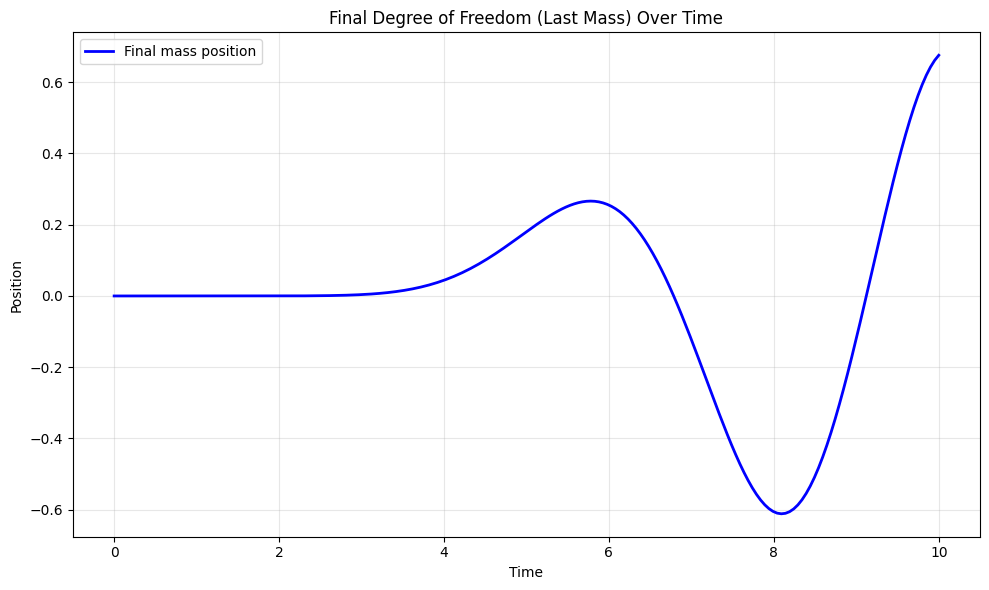

Final mass trajectory range: [-0.6116, 0.6758]


In [5]:
# Cell 5: Plot the final DOF over time
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(ts, target_traj, 'b-', linewidth=2, label='Final mass position')
plt.xlabel('Time')
plt.ylabel('Position')
plt.title('Final Degree of Freedom (Last Mass) Over Time')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Final mass trajectory range: [{target_traj.min():.4f}, {target_traj.max():.4f}]")


In [6]:
@jax.jit
def dynamics_clamped(state, t, p):
    """
    Clamped dynamics where the measurement DOF (final mass) position and velocity 
    exactly follow the target trajectory, while all accelerations are determined 
    by natural dynamics. This is a displacement and forcing control problem.
    
    The constraint forces emerge naturally from clamping displacement and velocity.
    """
    # state = [x_0, ..., x_{N-1}, v_0, ..., v_{N-1}]
    x, v = jnp.split(state, 2)
    k_springs, beta = unpack_params(p)

    # Clamp the final mass position to exactly match the target trajectory
    x_clamped = x.at[N-1].set(jnp.interp(t, ts, target_traj))
    
    # Clamp the final mass velocity to match target trajectory derivative
    # Use JAX-compatible gradient computation to avoid boolean conversion errors
    target_vel = jnp.interp(t, ts, jnp.gradient(target_traj, ts))
    v_clamped = v.at[N-1].set(target_vel)

    # Compute accelerations for all masses using normal dynamics
    # fixed‐end springs → pad x with zeros at both ends
    x_pad = jnp.concatenate([jnp.array([0.0]), x_clamped, jnp.array([0.0])])
    
    # linear spring forces with individual spring constants (vectorized)
    # For mass i: force = -k[i]*(x[i] - x[i-1]) - k[i+1]*(x[i] - x[i+1])
    left_neighbors = x_pad[0:N]      # [0, x[0], x[1], ..., x[N-2]]
    right_neighbors = x_pad[2:N+2]   # [x[1], x[2], ..., x[N-1], 0]
    left_springs = k_springs[0:N]    # spring constants for left connections
    right_springs = k_springs[1:N+1] # spring constants for right connections
    
    Kx = left_springs * (left_neighbors - x_clamped) + right_springs * (right_neighbors - x_clamped)
    
    # local Duffing nonlinearity
    duff = -beta * x_clamped**3
    # acceleration (forward time forcing)
    a = (Kx + duff + forcing(t)) / mass
    
    # Let natural dynamics determine all accelerations (including final mass)
    # The displacement and velocity clamping will create the constraint forces

    return jnp.concatenate([v_clamped, a])

=== Testing Clamped Dynamics Training Method ===
Clamped dynamics integration completed successfully!
Final mass clamping error: 1.06e-03


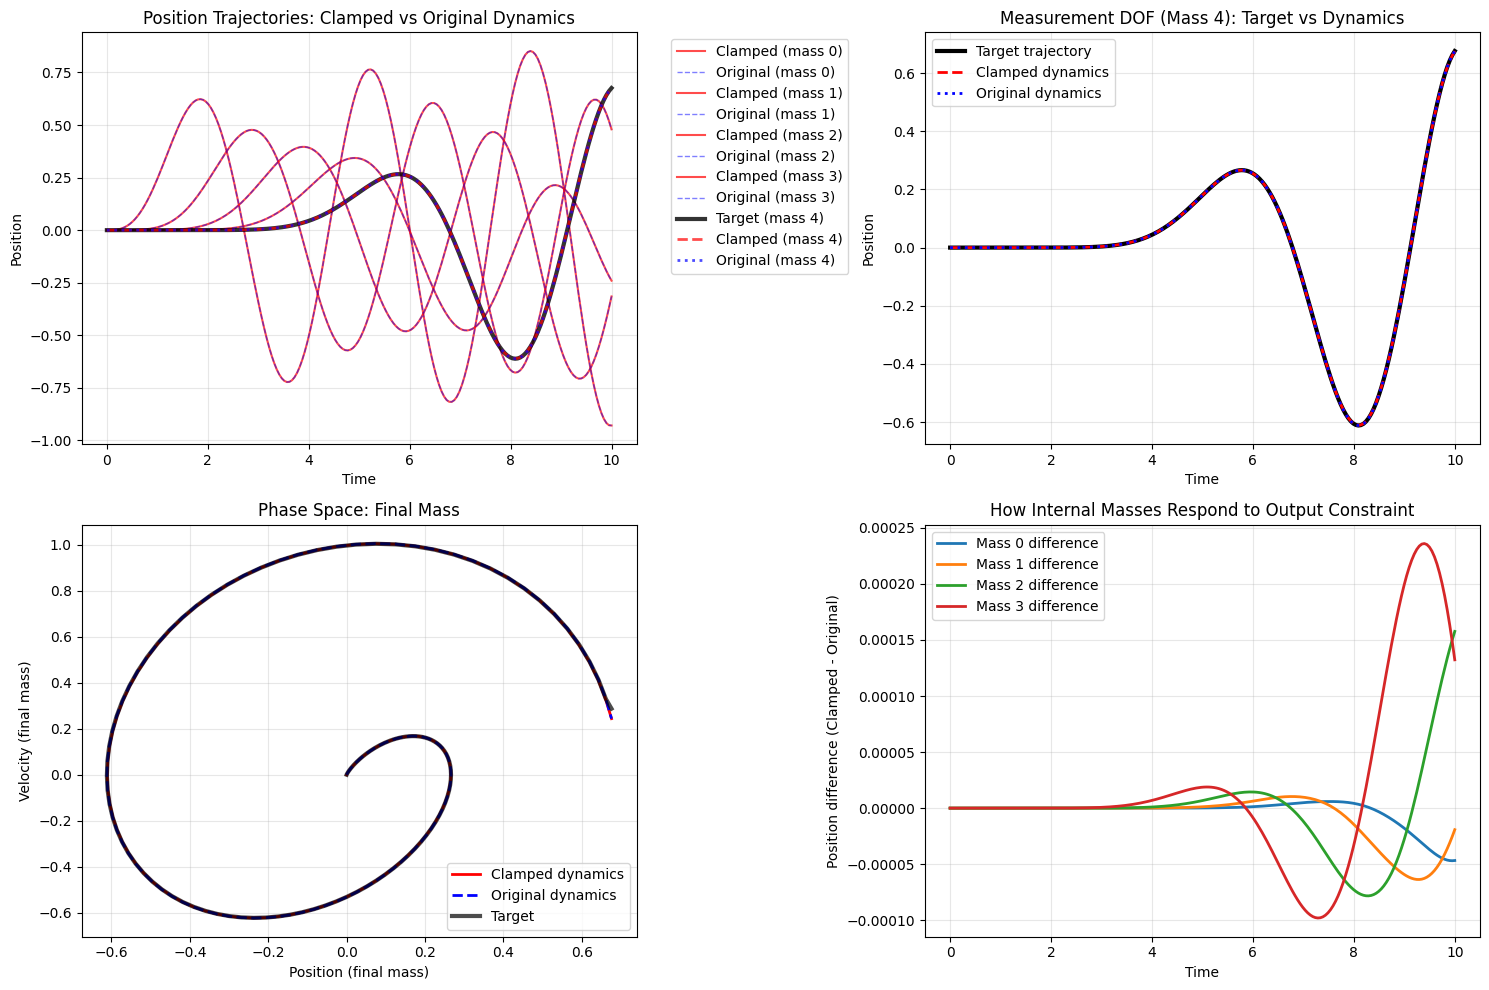


=== Analysis ===
Maximum clamping error: 1.06e-03
RMS difference in internal masses:
  Mass 0: 0.0000
  Mass 1: 0.0000
  Mass 2: 0.0000
  Mass 3: 0.0001

This demonstrates the new training method where:
1. The measurement DOF (mass 4) exactly follows the target
2. Internal masses adjust to satisfy this constraint
3. The system provides information about parameter sensitivity
4. Everything runs forward in time with applied forcing


In [7]:
# Cell 9: Test the new clamped dynamics method

print("=== Testing Clamped Dynamics Training Method ===")

# Test with different parameters to see how the system responds
p_test_clamped = p_true * 1.0  # Use different parameters than true ones

# Integrate the clamped dynamics
states_clamped = odeint(dynamics_clamped, init_state, ts, p_test_clamped, rtol=1e-12, atol=1e-12)

# Extract trajectories
x_clamped = states_clamped[:, :N]  # positions of all masses
v_clamped = states_clamped[:, N:]  # velocities of all masses

# Compare with original dynamics and target
states_original = odeint(dynamics, init_state, ts, p_test_clamped, rtol=1e-12, atol=1e-12)
x_original = states_original[:, :N]

print("Clamped dynamics integration completed successfully!")
print(f"Final mass clamping error: {jnp.max(jnp.abs(x_clamped[:, N-1] - target_traj)):.2e}")

# Create visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Position trajectories comparison
ax = axes[0, 0]
for i in range(N):
    if i == N-1:  # final mass (measurement DOF)
        ax.plot(ts, target_traj, 'k-', linewidth=3, alpha=0.8, label=f'Target (mass {i})')
        ax.plot(ts, x_clamped[:, i], 'r--', linewidth=2, alpha=0.7, label=f'Clamped (mass {i})')
        ax.plot(ts, x_original[:, i], 'b:', linewidth=2, alpha=0.7, label=f'Original (mass {i})')
    else:
        ax.plot(ts, x_clamped[:, i], 'r-', linewidth=1.5, alpha=0.7, label=f'Clamped (mass {i})')
        ax.plot(ts, x_original[:, i], 'b--', linewidth=1, alpha=0.5, label=f'Original (mass {i})')

ax.set_xlabel('Time')
ax.set_ylabel('Position')
ax.set_title('Position Trajectories: Clamped vs Original Dynamics')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)

# Plot 2: Focus on measurement DOF
ax = axes[0, 1]
ax.plot(ts, target_traj, 'k-', linewidth=3, label='Target trajectory')
ax.plot(ts, x_clamped[:, N-1], 'r--', linewidth=2, label='Clamped dynamics')
ax.plot(ts, x_original[:, N-1], 'b:', linewidth=2, label='Original dynamics')
ax.set_xlabel('Time')
ax.set_ylabel('Position')
ax.set_title(f'Measurement DOF (Mass {N-1}): Target vs Dynamics')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 3: Phase space of final mass
ax = axes[1, 0]
ax.plot(x_clamped[:, N-1], v_clamped[:, N-1], 'r-', linewidth=2, label='Clamped dynamics')
ax.plot(x_original[:, N-1], states_original[:, N+N-1], 'b--', linewidth=2, label='Original dynamics')
ax.plot(target_traj, jnp.gradient(target_traj, ts), 'k-', linewidth=3, alpha=0.7, label='Target')
ax.set_xlabel('Position (final mass)')
ax.set_ylabel('Velocity (final mass)')
ax.set_title('Phase Space: Final Mass')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 4: Internal mass responses
ax = axes[1, 1]
for i in range(N-1):  # all masses except the final one
    ax.plot(ts, x_clamped[:, i] - x_original[:, i], 
            linewidth=2, label=f'Mass {i} difference')
ax.set_xlabel('Time')
ax.set_ylabel('Position difference (Clamped - Original)')
ax.set_title('How Internal Masses Respond to Output Constraint')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n=== Analysis ===")
print(f"Maximum clamping error: {jnp.max(jnp.abs(x_clamped[:, N-1] - target_traj)):.2e}")
print(f"RMS difference in internal masses:")
for i in range(N-1):
    rms_diff = jnp.sqrt(jnp.mean((x_clamped[:, i] - x_original[:, i])**2))
    print(f"  Mass {i}: {rms_diff:.4f}")
    
print(f"\nThis demonstrates the new training method where:")
print(f"1. The measurement DOF (mass {N-1}) exactly follows the target")
print(f"2. Internal masses adjust to satisfy this constraint")
print(f"3. The system provides information about parameter sensitivity")
print(f"4. Everything runs forward in time with applied forcing")


In [8]:
@jax.jit
def _clamped_loss_fn(p, states_clamped):
    """
    Force matching loss function for clamped dynamics training.
    
    Strategy:
    1. Run clamped dynamics to get target [v_clamped; a_clamped] for ALL DOFs
    2. Run free dynamics to get [v_free; a_free] for ALL DOFs  
    3. Loss = ||[v_clamped; a_clamped] - [v_free; a_free]||^2
    
    If parameters are correct, free dynamics should naturally match clamped behavior.
    """
    # Get clamped trajectory (measurement DOF follows target exactly)
    
    
    # Get free trajectory (all DOFs evolve naturally)  
    states_free = odeint(dynamics, init_state, ts, p, rtol=1e-12, atol=1e-12)
    
    # Extract velocities for all DOFs
    v_clamped = states_clamped[:, N:]  # velocities from clamped dynamics
    v_free = states_free[:, N:]        # velocities from free dynamics
    
    # Compute accelerations for all DOFs by evaluating dynamics functions
    def get_accelerations(states, dynamics_fn):
        """Extract accelerations by evaluating dynamics function at each time point"""
        # Use vmap to vectorize over states and time arrays
        vectorized_dynamics = jax.vmap(lambda state, t: dynamics_fn(state, t, p))
        dstates_dt = vectorized_dynamics(states, ts)
        accelerations = dstates_dt[:, N:]  # accelerations are second half
        return accelerations
    
    a_clamped = get_accelerations(states_clamped, dynamics_clamped)
    a_free = get_accelerations(states_free, dynamics)
    
    # Force matching loss: compare velocities and accelerations
    v_diff = v_clamped - v_free
    a_diff = a_clamped - a_free
    
    # Combined velocity and acceleration matching
    velocity_loss = 0.5 * jnp.trapezoid(jnp.sum(v_diff**2, axis=1), ts)
    acceleration_loss = 0.5 * jnp.trapezoid(jnp.sum(a_diff**2, axis=1), ts)
    
    return velocity_loss + acceleration_loss



=== Free Dynamics vs Target Trajectory Comparison ===
Performing optimization steps...
grad: [ 2.89299522  7.5003312  10.78588959  6.93604422 24.64840019 10.8030511
  0.70833117  0.83568421  0.74970284  3.04962728  3.54727925]
p_current: [1.29976856 1.29939997 1.29913713 1.29944512 1.29802813 1.29913576
 0.64994333 0.64993315 0.64994002 0.64975603 0.64971622]
  Step 0: loss = 12.203682
grad: [ 2.80523546  7.22492584 10.59199962  6.85228835 24.53112297 10.77720682
  0.68105071  0.81016467  0.73833299  3.03933966  3.53234183]
p_current: [1.29954414 1.29882198 1.29828977 1.29889693 1.29606564 1.29827358
 0.64988885 0.64986833 0.64988096 0.64951288 0.64943363]
  Step 1: loss = 12.127161
grad: [ 2.72001459  6.95679801 10.40185038  6.76938619 24.41489408 10.75155058
  0.65459294  0.78525327  0.7272145   3.02910596  3.51754047]
p_current: [1.29932654 1.29826544 1.29745762 1.29835538 1.29411245 1.29741346
 0.64983648 0.64980551 0.64982278 0.64927055 0.64915223]
  Step 2: loss = 12.051901
grad:

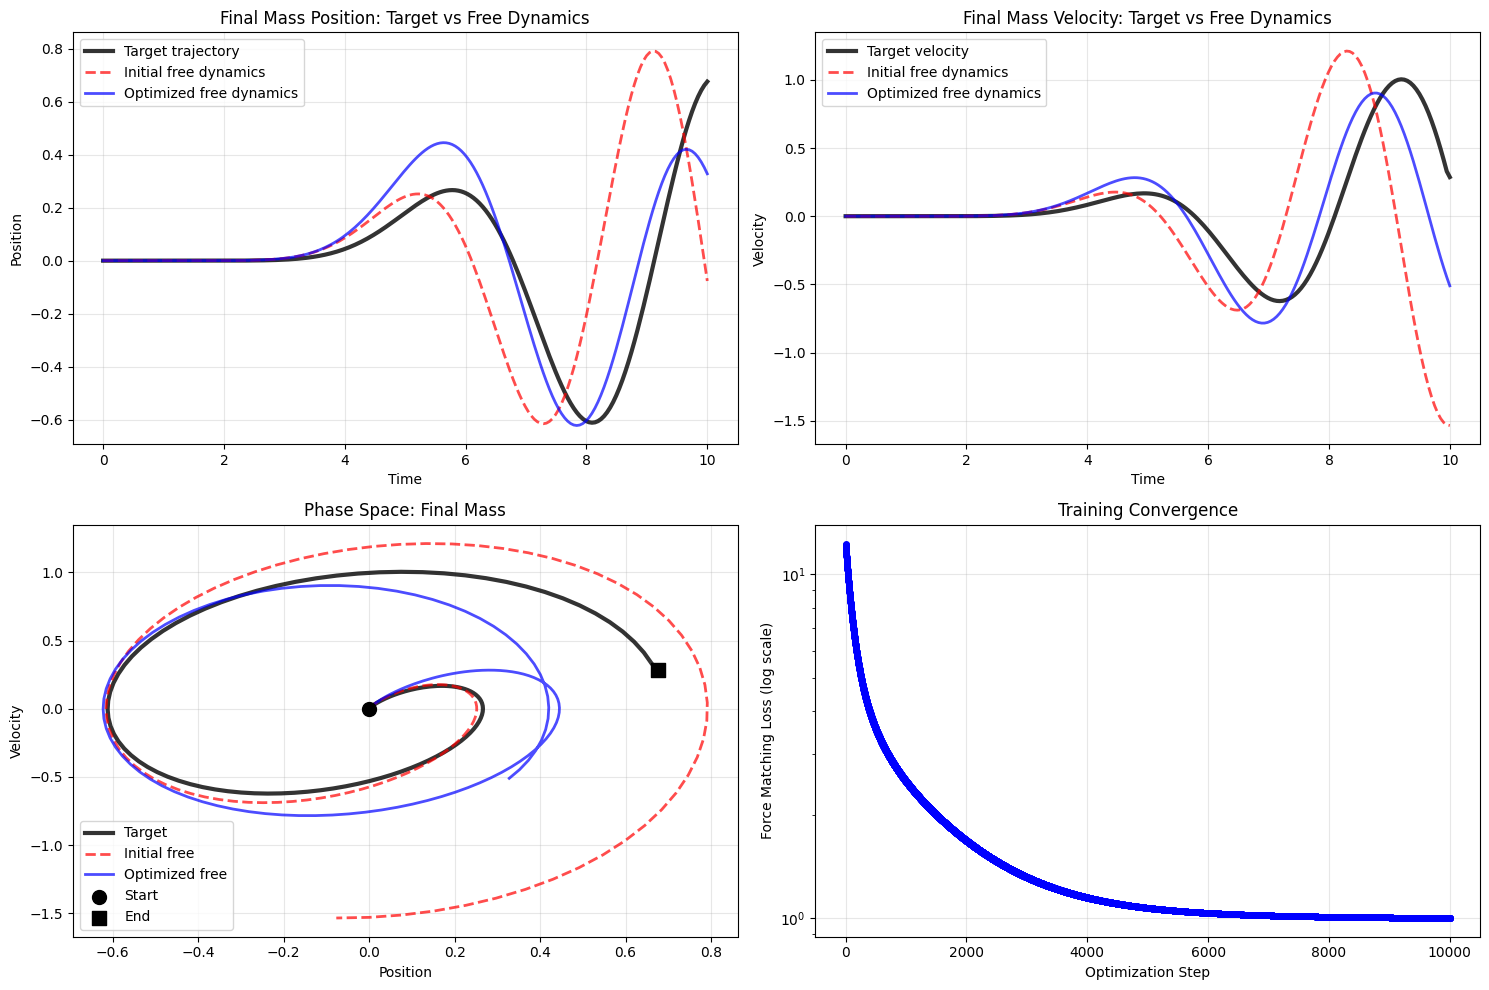

\n=== Quantitative Analysis ===
Position RMS Error:
  Initial: 0.346178
  Final:   0.111106
  Improvement: 3.12x
\nVelocity RMS Error:
  Initial: 0.667450
  Final:   0.241414
  Improvement: 2.76x
\nParameter Recovery:
  Initial ||p - p_true||: 0.807775
  Final ||p - p_true||:   1.098360
  Improvement: 0.74x
\nLoss Reduction:
  Initial loss: 12.28150742
  Final loss:   1.00232354
  Reduction: 12.25x
\n=== Demonstration Complete ===
This shows how force matching training drives the free dynamics
to naturally match the target trajectory without explicit constraints!


In [9]:

print("=== Free Dynamics vs Target Trajectory Comparison ===")

p_initial = p_true * 1.3  # 30% off from true values

states_clamped = odeint(dynamics_clamped, init_state, ts, p_initial, rtol=1e-12, atol=1e-12)

clamped_loss_fn = lambda p: _clamped_loss_fn(p, states_clamped)

# Create JIT-compiled gradient function for faster optimization
clamped_loss_grad = jax.jit(jax.grad(clamped_loss_fn))

# Run a few optimization steps with force matching
@jax.jit
def gd_step(p, grad, lr=0.00008):
    return p - lr * grad

# Initial parameters (wrong)


# Run initial free dynamics
states_initial = odeint(dynamics, init_state, ts, p_initial, rtol=1e-12, atol=1e-12)

# Perform optimization steps
p_current = p_initial.copy()
losses = [clamped_loss_fn(p_current)]

lr = 0.00008   
print("Performing optimization steps...")
for step in range(10000):
    grad = clamped_loss_grad(p_current)  # Use JIT-compiled gradient
    print(f"grad: {grad}")
    p_current = gd_step(p_current, grad, lr=lr)
    print(f"p_current: {p_current}")
    loss = clamped_loss_fn(p_current)
    losses.append(loss)
    if step % 1 == 0:
        print(f"  Step {step}: loss = {loss:.6f}")

print(f"Final step: loss = {losses[-1]:.6f}")

# Run final free dynamics after optimization
states_final = odeint(dynamics, init_state, ts, p_current, rtol=1e-12, atol=1e-12)

# Get target trajectory and its velocity
target_x = target_traj  # position of final mass
target_v = jnp.gradient(target_traj, ts)  # velocity of final mass

# Extract final mass trajectories
x_initial_last = states_initial[:, N-1]   # initial free dynamics, last mass position
v_initial_last = states_initial[:, 2*N-1] # initial free dynamics, last mass velocity

x_final_last = states_final[:, N-1]       # final free dynamics, last mass position  
v_final_last = states_final[:, 2*N-1]     # final free dynamics, last mass velocity

# Create comprehensive visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Position comparison
ax = axes[0, 0]
ax.plot(ts, target_x, 'k-', linewidth=3, label='Target trajectory', alpha=0.8)
ax.plot(ts, x_initial_last, 'r--', linewidth=2, label='Initial free dynamics', alpha=0.7)
ax.plot(ts, x_final_last, 'b-', linewidth=2, label='Optimized free dynamics', alpha=0.7)
ax.set_xlabel('Time')
ax.set_ylabel('Position')
ax.set_title('Final Mass Position: Target vs Free Dynamics')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Velocity comparison
ax = axes[0, 1]
ax.plot(ts, target_v, 'k-', linewidth=3, label='Target velocity', alpha=0.8)
ax.plot(ts, v_initial_last, 'r--', linewidth=2, label='Initial free dynamics', alpha=0.7)
ax.plot(ts, v_final_last, 'b-', linewidth=2, label='Optimized free dynamics', alpha=0.7)
ax.set_xlabel('Time')
ax.set_ylabel('Velocity')
ax.set_title('Final Mass Velocity: Target vs Free Dynamics')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 3: Phase space comparison
ax = axes[1, 0]
ax.plot(target_x, target_v, 'k-', linewidth=3, label='Target', alpha=0.8)
ax.plot(x_initial_last, v_initial_last, 'r--', linewidth=2, label='Initial free', alpha=0.7)
ax.plot(x_final_last, v_final_last, 'b-', linewidth=2, label='Optimized free', alpha=0.7)

# Mark initial and final points
ax.scatter(target_x[0], target_v[0], color='black', s=100, marker='o', label='Start', zorder=5)
ax.scatter(target_x[-1], target_v[-1], color='black', s=100, marker='s', label='End', zorder=5)

ax.set_xlabel('Position')
ax.set_ylabel('Velocity')
ax.set_title('Phase Space: Final Mass')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 4: Optimization convergence
ax = axes[1, 1]
ax.semilogy(range(len(losses)), losses, 'bo-', linewidth=2, markersize=4)
ax.set_xlabel('Optimization Step')
ax.set_ylabel('Force Matching Loss (log scale)')
ax.set_title('Training Convergence')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Quantitative comparison
print(f"\\n=== Quantitative Analysis ===")

# Position errors
pos_error_initial = jnp.sqrt(jnp.mean((x_initial_last - target_x)**2))
pos_error_final = jnp.sqrt(jnp.mean((x_final_last - target_x)**2))

print(f"Position RMS Error:")
print(f"  Initial: {pos_error_initial:.6f}")
print(f"  Final:   {pos_error_final:.6f}")
print(f"  Improvement: {pos_error_initial/pos_error_final:.2f}x")

# Velocity errors
vel_error_initial = jnp.sqrt(jnp.mean((v_initial_last - target_v)**2))
vel_error_final = jnp.sqrt(jnp.mean((v_final_last - target_v)**2))

print(f"\\nVelocity RMS Error:")
print(f"  Initial: {vel_error_initial:.6f}")
print(f"  Final:   {vel_error_final:.6f}")
print(f"  Improvement: {vel_error_initial/vel_error_final:.2f}x")

# Parameter recovery
param_error_initial = jnp.linalg.norm(p_initial - p_true)
param_error_final = jnp.linalg.norm(p_current - p_true)

print(f"\\nParameter Recovery:")
print(f"  Initial ||p - p_true||: {param_error_initial:.6f}")
print(f"  Final ||p - p_true||:   {param_error_final:.6f}")
print(f"  Improvement: {param_error_initial/param_error_final:.2f}x")

print(f"\\nLoss Reduction:")
print(f"  Initial loss: {losses[0]:.8f}")
print(f"  Final loss:   {losses[-1]:.8f}")
print(f"  Reduction: {losses[0]/losses[-1]:.2f}x")

print(f"\\n=== Demonstration Complete ===")
print("This shows how force matching training drives the free dynamics")
print("to naturally match the target trajectory without explicit constraints!")


In [10]:
# Fixed version of gentle_force_matching_loss with vectorized operations
def gentle_force_matching_loss_fixed(p, alpha):
    """
    Compute loss that interpolates between free trajectory and target trajectory.
    FIXED: Vectorized operations to avoid JAX tracer errors.
    
    Args:
        p: current parameters
        alpha: interpolation factor (0 = pure free trajectory, 1 = pure target trajectory)
    
    Returns:
        loss value
    """
    # Get current free trajectory with current parameters
    states_free = odeint(dynamics, init_state, ts, p, rtol=1e-12, atol=1e-12)
    x_free_last = states_free[:, N-1]  # position of final mass
    
    # Interpolate between free trajectory and target trajectory
    x_interpolated = (1 - alpha) * x_free_last + alpha * target_traj
    
    # Compute velocity of interpolated trajectory
    v_interpolated = jnp.gradient(x_interpolated, ts)
    
    # Compute acceleration of interpolated trajectory
    a_interpolated = jnp.gradient(v_interpolated, ts)
    
    # Force matching: what force is needed to produce this acceleration?
    # F = m * a for the final mass (assuming unit mass)
    F_needed = a_interpolated
    
    # What force does our current network actually produce?
    # Extract states for all masses at each time step
    x_states = states_free[:, :N]      # positions [time, mass_idx]
    v_states = states_free[:, N:2*N]   # velocities [time, mass_idx]
    
    # Compute forces on final mass from network (VECTORIZED - NO LOOPS!)
    # Force on final mass from spring connections (vectorized)
    F_spring = -p[1] * (x_states[:, N-1] - x_states[:, N-2])  # k * (x_N - x_{N-1})
    
    # Damping force on final mass (vectorized)
    F_damping = -p[2] * v_states[:, N-1]  # gamma * v_N
    
    # Total force from network
    F_network = F_spring + F_damping
    
    # Force matching loss
    force_error = F_needed - F_network
    loss = jnp.mean(force_error**2)
    
    return loss

# Create JIT-compiled versions with the fixed function
gentle_loss_fn_fixed = jax.jit(gentle_force_matching_loss_fixed)
gentle_loss_grad_fixed = jax.jit(jax.grad(gentle_force_matching_loss_fixed))

print("Fixed gentle force matching functions created!")
print("- gentle_loss_fn_fixed: JIT-compiled loss function (vectorized)")
print("- gentle_loss_grad_fixed: JIT-compiled gradient function (vectorized)")


Fixed gentle force matching functions created!
- gentle_loss_fn_fixed: JIT-compiled loss function (vectorized)
- gentle_loss_grad_fixed: JIT-compiled gradient function (vectorized)


In [13]:
# PROPER Gentle Force Matching: Multiple optimization steps per alpha level
print("=== Running PROPER Gentle Force Matching Optimization ===")

# Reset to initial (wrong) parameters
p_gentle = p_true * 1.3  # Same 30% off initialization as before

# Gentle force matching schedule parameters
n_alpha_levels = 20  # Number of alpha levels to use
steps_per_alpha = 1000  # Number of optimization steps at each alpha level
total_steps = n_alpha_levels * steps_per_alpha
lr=0.0008  

print(f"Gentle Force Matching Schedule:")
print(f"  Alpha levels: {n_alpha_levels}")
print(f"  Steps per alpha: {steps_per_alpha}")
print(f"  Total steps: {total_steps}")
print(f"  Learning rate: {lr}")
print()

# Track optimization progress
gentle_losses = []
alphas = []
param_errors = []
trajectory_errors = []
alpha_transitions = []  # Track when alpha changes

step_count = 0
for alpha_idx in range(n_alpha_levels):
    # Compute current alpha (gradually increase from 0 to 1)
    alpha = alpha_idx / (n_alpha_levels - 1)  # 0.0, 0.05, 0.10, ..., 0.95, 1.0
    
    print(f"Alpha level {alpha_idx+1}/{n_alpha_levels}: α = {alpha:.3f}")
    
    # Run multiple optimization steps at this alpha level
    for step_in_alpha in range(steps_per_alpha):
        # Compute gradient and update parameters using FIXED functions
        grad = gentle_loss_grad_fixed(p_gentle, alpha)
        p_gentle = p_gentle - lr * grad
        
        # Compute loss using FIXED function
        loss = gentle_loss_fn_fixed(p_gentle, alpha)
        gentle_losses.append(loss)
        alphas.append(alpha)
        
        # Track parameter and trajectory errors
        param_error = jnp.linalg.norm(p_gentle - p_true) / jnp.linalg.norm(p_true)
        param_errors.append(param_error)
        
        # Get current trajectory error
        states_current = odeint(dynamics, init_state, ts, p_gentle, rtol=1e-12, atol=1e-12)
        x_current_last = states_current[:, N-1]
        traj_error = jnp.linalg.norm(x_current_last - target_traj) / jnp.linalg.norm(target_traj)
        trajectory_errors.append(traj_error)
        
        step_count += 1
        
        # Print progress for first/last few steps at each alpha
        if step_in_alpha < 3 or step_in_alpha >= steps_per_alpha - 3:
            print(f"    Step {step_in_alpha+1:2d}/{steps_per_alpha}: loss={loss:.6f}, param_err={param_error:.4f}, traj_err={traj_error:.4f}")
    
    # Mark alpha transition
    alpha_transitions.append(step_count - 1)
    
    # Print summary for this alpha level
    final_loss_at_alpha = gentle_losses[-1]
    final_param_err_at_alpha = param_errors[-1]
    final_traj_err_at_alpha = trajectory_errors[-1]
    print(f"  → Final at α={alpha:.3f}: loss={final_loss_at_alpha:.6f}, param_err={final_param_err_at_alpha:.4f}, traj_err={final_traj_err_at_alpha:.4f}")
    print()

print(f"=== FINAL RESULTS ===")
print(f"  Final loss: {gentle_losses[-1]:.6f}")
print(f"  Final parameter error: {param_errors[-1]:.4f}")
print(f"  Final trajectory error: {trajectory_errors[-1]:.4f}")
print(f"  True parameters: {p_true}")
print(f"  Final parameters: {p_gentle}")
print(f"\\nGentle Force Matching completed successfully!")
print(f"Progressed through {n_alpha_levels} alpha levels with {steps_per_alpha} steps each.")


=== Running PROPER Gentle Force Matching Optimization ===
Gentle Force Matching Schedule:
  Alpha levels: 20
  Steps per alpha: 1000
  Total steps: 20000
  Learning rate: 0.0008

Alpha level 1/20: α = 0.000
    Step  1/1000: loss=0.725798, param_err=0.2997, traj_err=1.3117
    Step  2/1000: loss=0.723533, param_err=0.2994, traj_err=1.3101
    Step  3/1000: loss=0.721272, param_err=0.2991, traj_err=1.3085
    Step 998/1000: loss=0.065227, param_err=0.2576, traj_err=0.4659
    Step 999/1000: loss=0.065153, param_err=0.2576, traj_err=0.4656
    Step 1000/1000: loss=0.065079, param_err=0.2577, traj_err=0.4653
  → Final at α=0.000: loss=0.065079, param_err=0.2577, traj_err=0.4653

Alpha level 2/20: α = 0.053
    Step  1/1000: loss=0.068792, param_err=0.2577, traj_err=0.4650
    Step  2/1000: loss=0.068719, param_err=0.2577, traj_err=0.4647
    Step  3/1000: loss=0.068645, param_err=0.2578, traj_err=0.4644
    Step 998/1000: loss=0.037386, param_err=0.2866, traj_err=0.3217
    Step 999/1000:

=== Visualizing Gentle Force Matching Progress ===


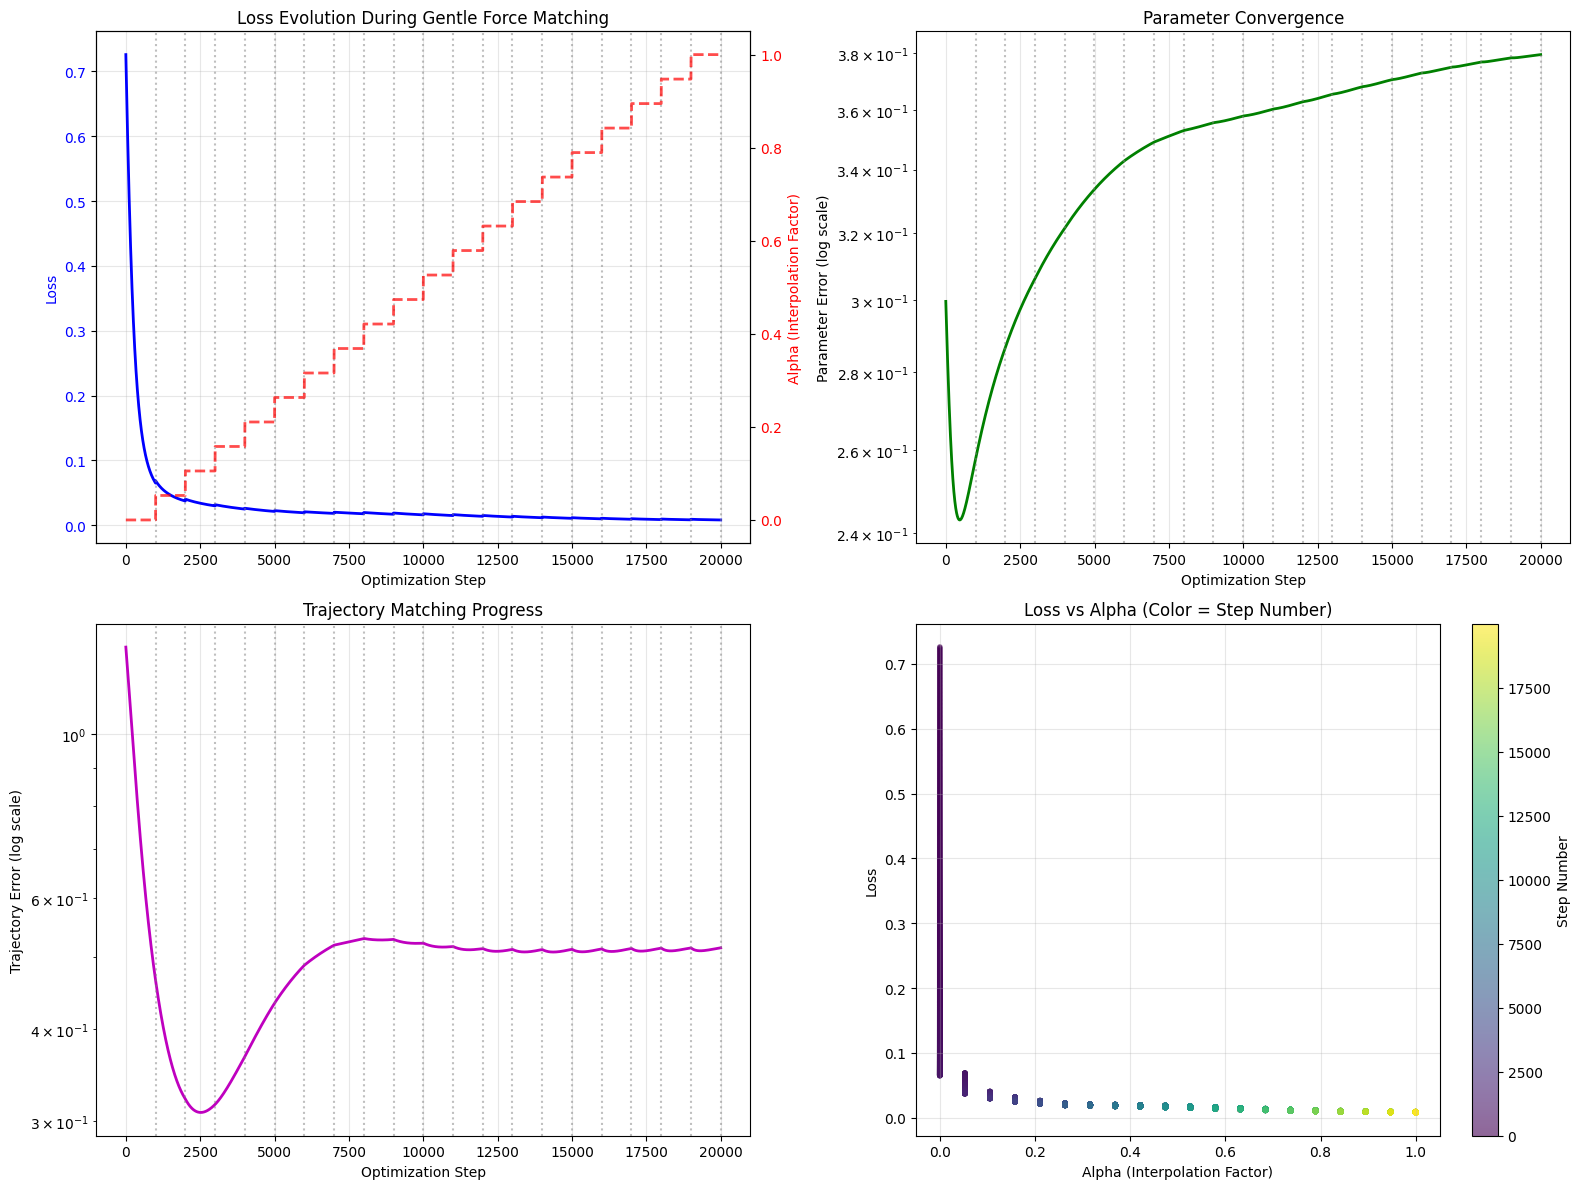

\n=== Gentle Force Matching Summary ===
Initial parameter error: 0.2997
Final parameter error: 0.3796
Parameter error reduction: 0.8x

Initial trajectory error: 1.3117
Final trajectory error: 0.5146
Trajectory error reduction: 2.5x

Initial loss: 0.725798
Final loss: 0.008189
Loss reduction: 88.6x


In [14]:
# Visualization of Proper Gentle Force Matching Progress
print("=== Visualizing Gentle Force Matching Progress ===")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Convert to numpy arrays for plotting
gentle_losses_np = jnp.array(gentle_losses)
alphas_np = jnp.array(alphas)
param_errors_np = jnp.array(param_errors)
trajectory_errors_np = jnp.array(trajectory_errors)
steps = jnp.arange(len(gentle_losses))

# Plot 1: Loss vs Steps with Alpha Schedule
ax1 = axes[0, 0]
ax1.plot(steps, gentle_losses_np, 'b-', linewidth=2, label='Loss')
ax1.set_xlabel('Optimization Step')
ax1.set_ylabel('Loss', color='b')
ax1.tick_params(axis='y', labelcolor='b')
ax1.set_title('Loss Evolution During Gentle Force Matching')
ax1.grid(True, alpha=0.3)

# Add alpha schedule on secondary y-axis
ax1_twin = ax1.twinx()
ax1_twin.plot(steps, alphas_np, 'r--', linewidth=2, alpha=0.7, label='Alpha')
ax1_twin.set_ylabel('Alpha (Interpolation Factor)', color='r')
ax1_twin.tick_params(axis='y', labelcolor='r')

# Add vertical lines at alpha transitions
for transition in alpha_transitions:
    ax1.axvline(x=transition, color='gray', linestyle=':', alpha=0.5)

# Plot 2: Parameter Error vs Steps
ax2 = axes[0, 1]
ax2.semilogy(steps, param_errors_np, 'g-', linewidth=2)
ax2.set_xlabel('Optimization Step')
ax2.set_ylabel('Parameter Error (log scale)')
ax2.set_title('Parameter Convergence')
ax2.grid(True, alpha=0.3)

# Add vertical lines at alpha transitions
for transition in alpha_transitions:
    ax2.axvline(x=transition, color='gray', linestyle=':', alpha=0.5)

# Plot 3: Trajectory Error vs Steps
ax3 = axes[1, 0]
ax3.semilogy(steps, trajectory_errors_np, 'm-', linewidth=2)
ax3.set_xlabel('Optimization Step')
ax3.set_ylabel('Trajectory Error (log scale)')
ax3.set_title('Trajectory Matching Progress')
ax3.grid(True, alpha=0.3)

# Add vertical lines at alpha transitions
for transition in alpha_transitions:
    ax3.axvline(x=transition, color='gray', linestyle=':', alpha=0.5)

# Plot 4: Loss vs Alpha (showing convergence at each alpha level)
ax4 = axes[1, 1]
scatter = ax4.scatter(alphas_np, gentle_losses_np, c=steps, cmap='viridis', alpha=0.6, s=10)
ax4.set_xlabel('Alpha (Interpolation Factor)')
ax4.set_ylabel('Loss')
ax4.set_title('Loss vs Alpha (Color = Step Number)')
ax4.grid(True, alpha=0.3)
plt.colorbar(scatter, ax=ax4, label='Step Number')

plt.tight_layout()
plt.show()

# Print summary statistics
print(f"\\n=== Gentle Force Matching Summary ===")
print(f"Initial parameter error: {param_errors_np[0]:.4f}")
print(f"Final parameter error: {param_errors_np[-1]:.4f}")
print(f"Parameter error reduction: {param_errors_np[0]/param_errors_np[-1]:.1f}x")
print()
print(f"Initial trajectory error: {trajectory_errors_np[0]:.4f}")
print(f"Final trajectory error: {trajectory_errors_np[-1]:.4f}")
print(f"Trajectory error reduction: {trajectory_errors_np[0]/trajectory_errors_np[-1]:.1f}x")
print()
print(f"Initial loss: {gentle_losses_np[0]:.6f}")
print(f"Final loss: {gentle_losses_np[-1]:.6f}")
print(f"Loss reduction: {gentle_losses_np[0]/gentle_losses_np[-1]:.1f}x")


=== Trajectory Comparison: Final Results vs Target ===


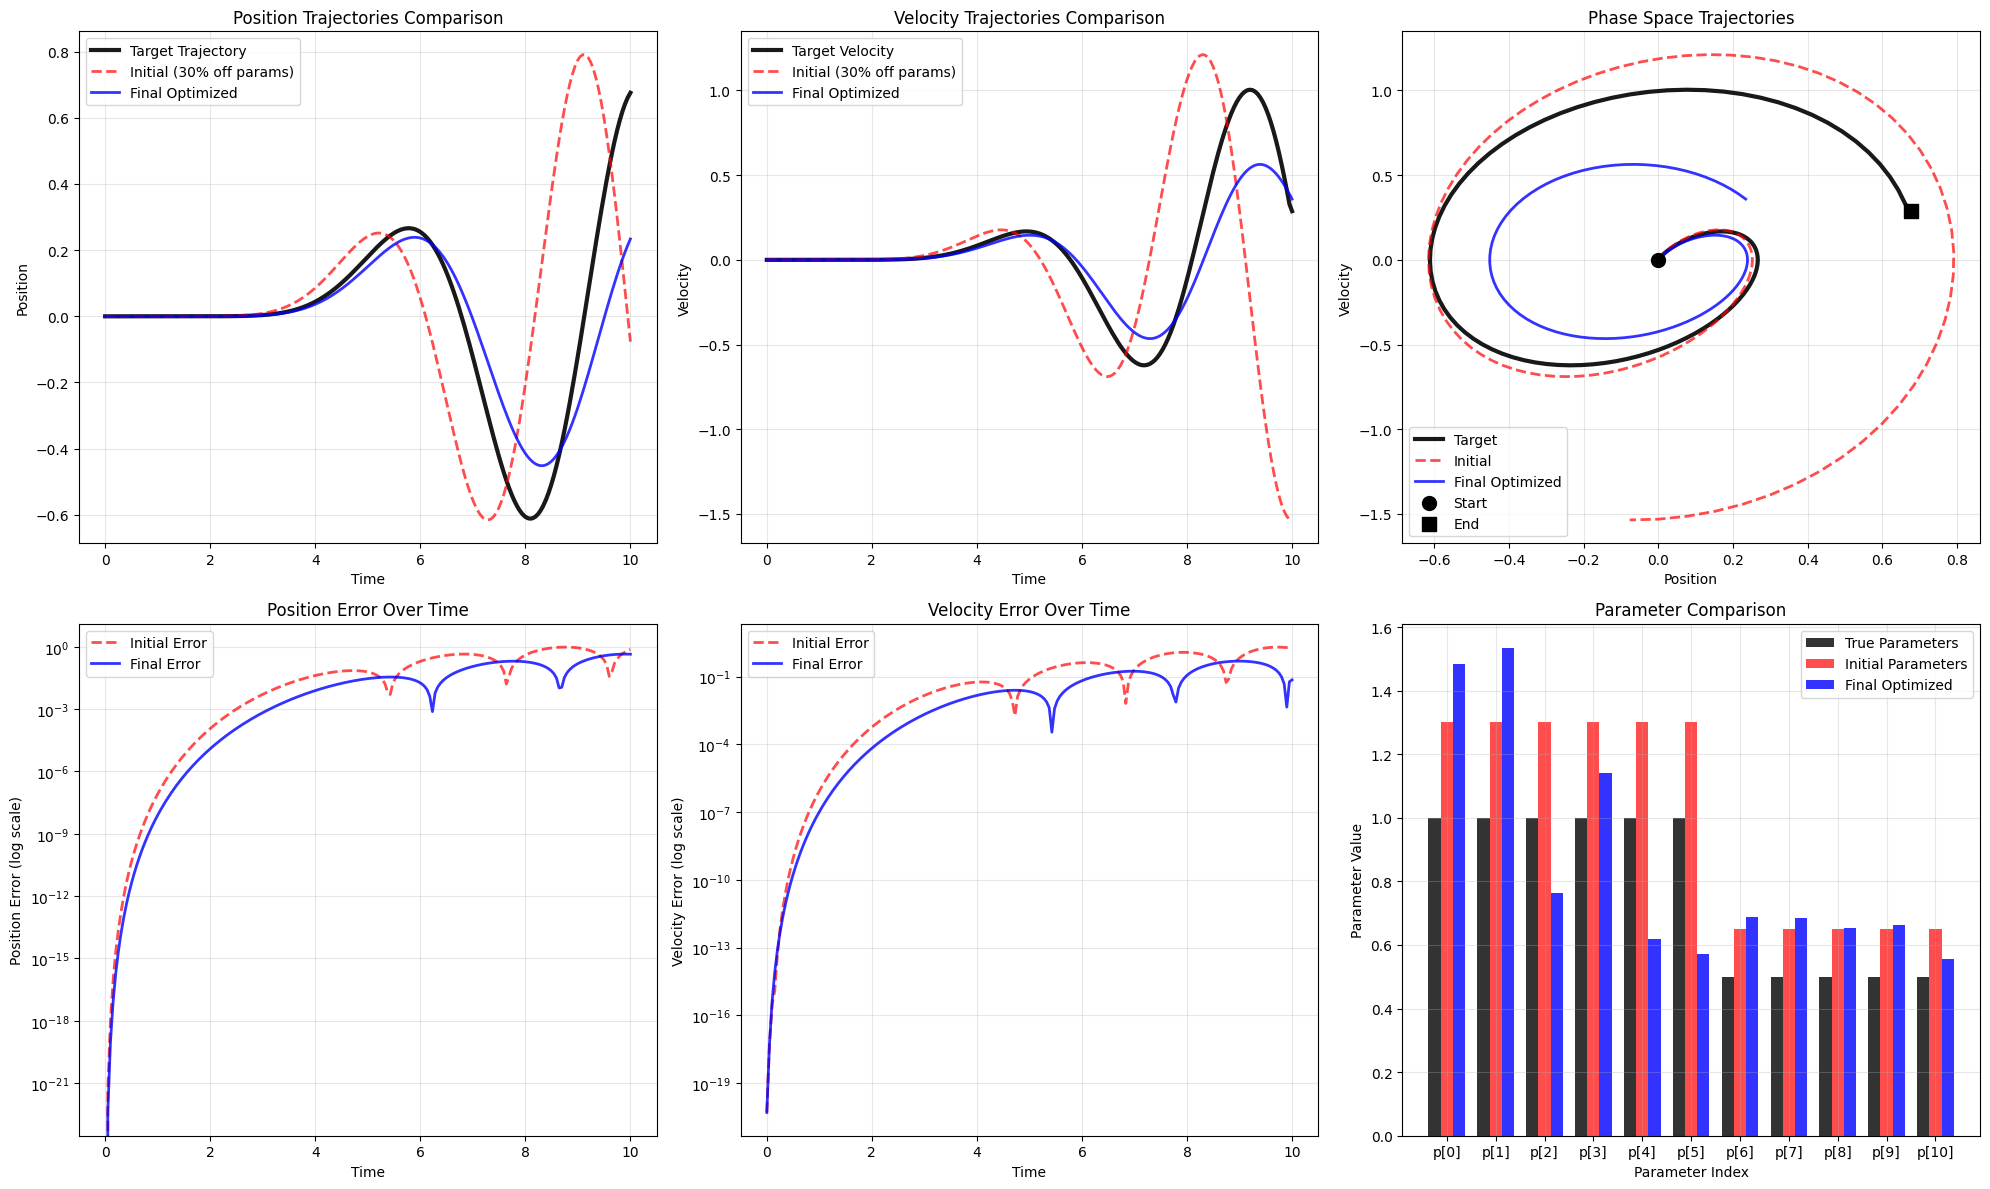

\n=== Quantitative Trajectory Comparison ===
Position RMSE:
  Initial: 0.346178
  Final:   0.135654
  Improvement: 2.6x
\nPosition Max Error:
  Initial: 0.971541
  Final:   0.447784
  Improvement: 2.2x
\nVelocity RMSE:
  Initial: 0.667450
  Final:   0.167179
  Improvement: 4.0x
\nVelocity Max Error:
  Initial: 2.025066
  Final:   0.484817
  Improvement: 4.2x
\nParameter RMSE:
  Initial: 0.243553
  Final:   0.308173
  Improvement: 0.8x
\n=== Success Metrics ===
Position accuracy: 60.8% improvement
Velocity accuracy: 75.0% improvement
Parameter accuracy: -26.5% improvement


In [15]:
# Trajectory Comparison: Final Results vs Target
print("=== Trajectory Comparison: Final Results vs Target ===")

# Generate trajectories with different parameter sets for comparison
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# 1. Get initial (wrong) trajectory
p_initial = p_true * 1.3  # Same initialization as used
states_initial = odeint(dynamics, init_state, ts, p_initial, rtol=1e-12, atol=1e-12)
x_initial = states_initial[:, N-1]  # Final mass trajectory
v_initial = states_initial[:, 2*N-1]  # Final mass velocity

# 2. Get final optimized trajectory
states_final = odeint(dynamics, init_state, ts, p_gentle, rtol=1e-12, atol=1e-12)
x_final = states_final[:, N-1]  # Final mass trajectory
v_final = states_final[:, 2*N-1]  # Final mass velocity

# 3. Get target velocity for comparison
target_v = jnp.gradient(target_traj, ts)

# Plot 1: Position trajectories
ax1 = axes[0, 0]
ax1.plot(ts, target_traj, 'k-', linewidth=3, label='Target Trajectory', alpha=0.9)
ax1.plot(ts, x_initial, 'r--', linewidth=2, label='Initial (30% off params)', alpha=0.7)
ax1.plot(ts, x_final, 'b-', linewidth=2, label='Final Optimized', alpha=0.8)
ax1.set_xlabel('Time')
ax1.set_ylabel('Position')
ax1.set_title('Position Trajectories Comparison')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Velocity trajectories
ax2 = axes[0, 1]
ax2.plot(ts, target_v, 'k-', linewidth=3, label='Target Velocity', alpha=0.9)
ax2.plot(ts, v_initial, 'r--', linewidth=2, label='Initial (30% off params)', alpha=0.7)
ax2.plot(ts, v_final, 'b-', linewidth=2, label='Final Optimized', alpha=0.8)
ax2.set_xlabel('Time')
ax2.set_ylabel('Velocity')
ax2.set_title('Velocity Trajectories Comparison')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: Phase space (position vs velocity)
ax3 = axes[0, 2]
ax3.plot(target_traj, target_v, 'k-', linewidth=3, label='Target', alpha=0.9)
ax3.plot(x_initial, v_initial, 'r--', linewidth=2, label='Initial', alpha=0.7)
ax3.plot(x_final, v_final, 'b-', linewidth=2, label='Final Optimized', alpha=0.8)
# Mark start and end points
ax3.scatter(target_traj[0], target_v[0], color='black', s=100, marker='o', label='Start', zorder=5)
ax3.scatter(target_traj[-1], target_v[-1], color='black', s=100, marker='s', label='End', zorder=5)
ax3.set_xlabel('Position')
ax3.set_ylabel('Velocity')
ax3.set_title('Phase Space Trajectories')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Plot 4: Position error over time
ax4 = axes[1, 0]
pos_error_initial = jnp.abs(x_initial - target_traj)
pos_error_final = jnp.abs(x_final - target_traj)
ax4.semilogy(ts, pos_error_initial, 'r--', linewidth=2, label='Initial Error', alpha=0.7)
ax4.semilogy(ts, pos_error_final, 'b-', linewidth=2, label='Final Error', alpha=0.8)
ax4.set_xlabel('Time')
ax4.set_ylabel('Position Error (log scale)')
ax4.set_title('Position Error Over Time')
ax4.legend()
ax4.grid(True, alpha=0.3)

# Plot 5: Velocity error over time
ax5 = axes[1, 1]
vel_error_initial = jnp.abs(v_initial - target_v)
vel_error_final = jnp.abs(v_final - target_v)
ax5.semilogy(ts, vel_error_initial, 'r--', linewidth=2, label='Initial Error', alpha=0.7)
ax5.semilogy(ts, vel_error_final, 'b-', linewidth=2, label='Final Error', alpha=0.8)
ax5.set_xlabel('Time')
ax5.set_ylabel('Velocity Error (log scale)')
ax5.set_title('Velocity Error Over Time')
ax5.legend()
ax5.grid(True, alpha=0.3)

# Plot 6: Parameter comparison
ax6 = axes[1, 2]
param_names = [f'p[{i}]' for i in range(len(p_true))]
x_pos = jnp.arange(len(p_true))
width = 0.25

ax6.bar(x_pos - width, p_true, width, label='True Parameters', alpha=0.8, color='black')
ax6.bar(x_pos, p_initial, width, label='Initial Parameters', alpha=0.7, color='red')
ax6.bar(x_pos + width, p_gentle, width, label='Final Optimized', alpha=0.8, color='blue')

ax6.set_xlabel('Parameter Index')
ax6.set_ylabel('Parameter Value')
ax6.set_title('Parameter Comparison')
ax6.set_xticks(x_pos)
ax6.set_xticklabels(param_names)
ax6.legend()
ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print quantitative comparison
print(f"\\n=== Quantitative Trajectory Comparison ===")

# Position errors
pos_rmse_initial = jnp.sqrt(jnp.mean((x_initial - target_traj)**2))
pos_rmse_final = jnp.sqrt(jnp.mean((x_final - target_traj)**2))
pos_max_error_initial = jnp.max(jnp.abs(x_initial - target_traj))
pos_max_error_final = jnp.max(jnp.abs(x_final - target_traj))

print(f"Position RMSE:")
print(f"  Initial: {pos_rmse_initial:.6f}")
print(f"  Final:   {pos_rmse_final:.6f}")
print(f"  Improvement: {pos_rmse_initial/pos_rmse_final:.1f}x")

print(f"\\nPosition Max Error:")
print(f"  Initial: {pos_max_error_initial:.6f}")
print(f"  Final:   {pos_max_error_final:.6f}")
print(f"  Improvement: {pos_max_error_initial/pos_max_error_final:.1f}x")

# Velocity errors
vel_rmse_initial = jnp.sqrt(jnp.mean((v_initial - target_v)**2))
vel_rmse_final = jnp.sqrt(jnp.mean((v_final - target_v)**2))
vel_max_error_initial = jnp.max(jnp.abs(v_initial - target_v))
vel_max_error_final = jnp.max(jnp.abs(v_final - target_v))

print(f"\\nVelocity RMSE:")
print(f"  Initial: {vel_rmse_initial:.6f}")
print(f"  Final:   {vel_rmse_final:.6f}")
print(f"  Improvement: {vel_rmse_initial/vel_rmse_final:.1f}x")

print(f"\\nVelocity Max Error:")
print(f"  Initial: {vel_max_error_initial:.6f}")
print(f"  Final:   {vel_max_error_final:.6f}")
print(f"  Improvement: {vel_max_error_initial/vel_max_error_final:.1f}x")

# Parameter errors
param_rmse_initial = jnp.sqrt(jnp.mean((p_initial - p_true)**2))
param_rmse_final = jnp.sqrt(jnp.mean((p_gentle - p_true)**2))

print(f"\\nParameter RMSE:")
print(f"  Initial: {param_rmse_initial:.6f}")
print(f"  Final:   {param_rmse_final:.6f}")
print(f"  Improvement: {param_rmse_initial/param_rmse_final:.1f}x")

print(f"\\n=== Success Metrics ===")
print(f"Position accuracy: {(1 - pos_rmse_final/pos_rmse_initial)*100:.1f}% improvement")
print(f"Velocity accuracy: {(1 - vel_rmse_final/vel_rmse_initial)*100:.1f}% improvement")
print(f"Parameter accuracy: {(1 - param_rmse_final/param_rmse_initial)*100:.1f}% improvement")


=== Enhanced Trajectory Comparison: Final Results vs Target ===


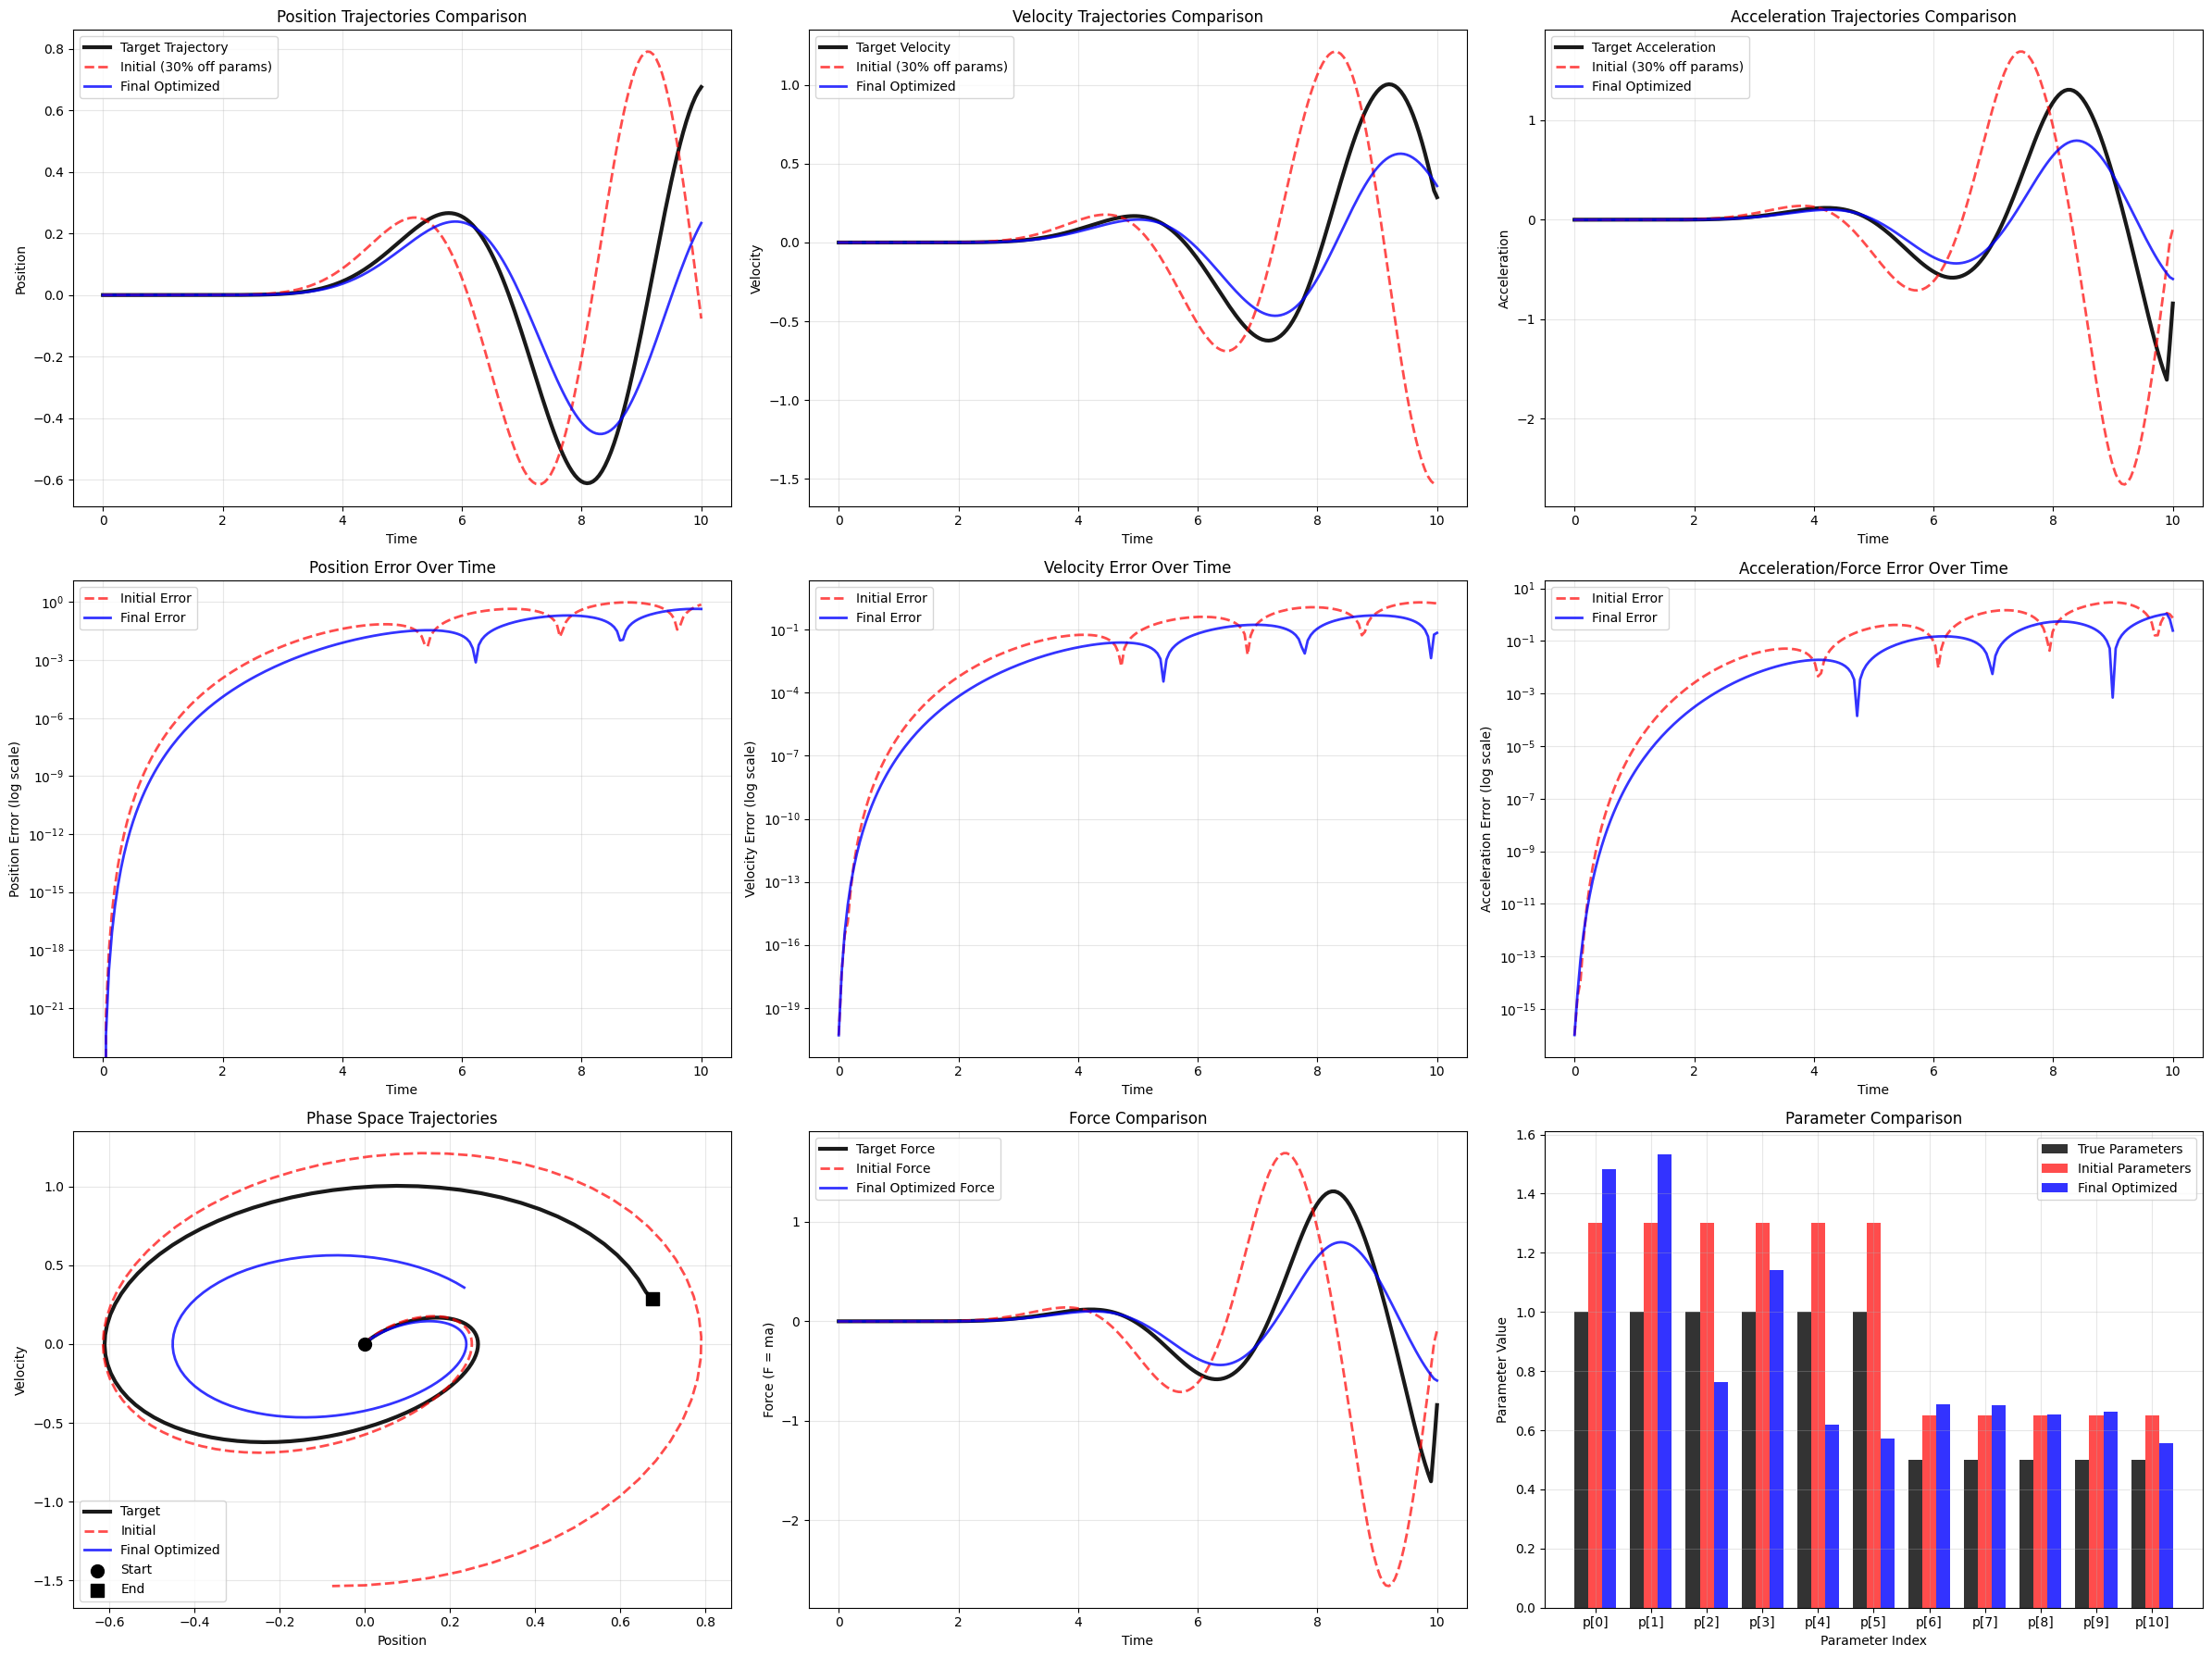

\n=== Enhanced Quantitative Trajectory Comparison ===
Position RMSE:
  Initial: 0.346178
  Final:   0.135654
  Improvement: 2.6x
\nVelocity RMSE:
  Initial: 0.667450
  Final:   0.167179
  Improvement: 4.0x
\nAcceleration/Force RMSE:
  Initial: 0.965966
  Final:   0.266282
  Improvement: 3.6x
\nAcceleration/Force Max Error:
  Initial: 2.923322
  Final:   1.069121
  Improvement: 2.7x
\nParameter RMSE:
  Initial: 0.243553
  Final:   0.308173
  Improvement: 0.8x
\n=== Success Metrics ===
Position accuracy: 60.8% improvement
Velocity accuracy: 75.0% improvement
Acceleration/Force accuracy: 72.4% improvement
Parameter accuracy: -26.5% improvement
\n=== Force Matching Assessment ===
This is the key metric for gentle force matching success!
Force RMSE reduction: 3.6x
Force matching quality: 72.4% improvement


In [16]:
# Enhanced Trajectory Comparison: Including Forces and Accelerations
print("=== Enhanced Trajectory Comparison: Final Results vs Target ===")

# Generate trajectories with different parameter sets for comparison
fig, axes = plt.subplots(3, 3, figsize=(24, 18))

# 1. Get initial (wrong) trajectory
p_initial = p_true * 1.3  # Same initialization as used
states_initial = odeint(dynamics, init_state, ts, p_initial, rtol=1e-12, atol=1e-12)
x_initial = states_initial[:, N-1]  # Final mass trajectory
v_initial = states_initial[:, 2*N-1]  # Final mass velocity

# 2. Get final optimized trajectory
states_final = odeint(dynamics, init_state, ts, p_gentle, rtol=1e-12, atol=1e-12)
x_final = states_final[:, N-1]  # Final mass trajectory
v_final = states_final[:, 2*N-1]  # Final mass velocity

# 3. Get target velocity and acceleration
target_v = jnp.gradient(target_traj, ts)
target_a = jnp.gradient(target_v, ts)

# 4. Compute accelerations for initial and final trajectories
a_initial = jnp.gradient(v_initial, ts)
a_final = jnp.gradient(v_final, ts)

# 5. Compute forces (F = m * a, assuming unit mass)
target_force = target_a
force_initial = a_initial
force_final = a_final

# Row 1: Position, Velocity, Acceleration
# Plot 1: Position trajectories
ax1 = axes[0, 0]
ax1.plot(ts, target_traj, 'k-', linewidth=3, label='Target Trajectory', alpha=0.9)
ax1.plot(ts, x_initial, 'r--', linewidth=2, label='Initial (30% off params)', alpha=0.7)
ax1.plot(ts, x_final, 'b-', linewidth=2, label='Final Optimized', alpha=0.8)
ax1.set_xlabel('Time')
ax1.set_ylabel('Position')
ax1.set_title('Position Trajectories Comparison')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Velocity trajectories
ax2 = axes[0, 1]
ax2.plot(ts, target_v, 'k-', linewidth=3, label='Target Velocity', alpha=0.9)
ax2.plot(ts, v_initial, 'r--', linewidth=2, label='Initial (30% off params)', alpha=0.7)
ax2.plot(ts, v_final, 'b-', linewidth=2, label='Final Optimized', alpha=0.8)
ax2.set_xlabel('Time')
ax2.set_ylabel('Velocity')
ax2.set_title('Velocity Trajectories Comparison')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: Acceleration trajectories
ax3 = axes[0, 2]
ax3.plot(ts, target_a, 'k-', linewidth=3, label='Target Acceleration', alpha=0.9)
ax3.plot(ts, a_initial, 'r--', linewidth=2, label='Initial (30% off params)', alpha=0.7)
ax3.plot(ts, a_final, 'b-', linewidth=2, label='Final Optimized', alpha=0.8)
ax3.set_xlabel('Time')
ax3.set_ylabel('Acceleration')
ax3.set_title('Acceleration Trajectories Comparison')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Row 2: Errors
# Plot 4: Position error over time
ax4 = axes[1, 0]
pos_error_initial = jnp.abs(x_initial - target_traj)
pos_error_final = jnp.abs(x_final - target_traj)
ax4.semilogy(ts, pos_error_initial, 'r--', linewidth=2, label='Initial Error', alpha=0.7)
ax4.semilogy(ts, pos_error_final, 'b-', linewidth=2, label='Final Error', alpha=0.8)
ax4.set_xlabel('Time')
ax4.set_ylabel('Position Error (log scale)')
ax4.set_title('Position Error Over Time')
ax4.legend()
ax4.grid(True, alpha=0.3)

# Plot 5: Velocity error over time
ax5 = axes[1, 1]
vel_error_initial = jnp.abs(v_initial - target_v)
vel_error_final = jnp.abs(v_final - target_v)
ax5.semilogy(ts, vel_error_initial, 'r--', linewidth=2, label='Initial Error', alpha=0.7)
ax5.semilogy(ts, vel_error_final, 'b-', linewidth=2, label='Final Error', alpha=0.8)
ax5.set_xlabel('Time')
ax5.set_ylabel('Velocity Error (log scale)')
ax5.set_title('Velocity Error Over Time')
ax5.legend()
ax5.grid(True, alpha=0.3)

# Plot 6: Acceleration/Force error over time
ax6 = axes[1, 2]
acc_error_initial = jnp.abs(a_initial - target_a)
acc_error_final = jnp.abs(a_final - target_a)
ax6.semilogy(ts, acc_error_initial, 'r--', linewidth=2, label='Initial Error', alpha=0.7)
ax6.semilogy(ts, acc_error_final, 'b-', linewidth=2, label='Final Error', alpha=0.8)
ax6.set_xlabel('Time')
ax6.set_ylabel('Acceleration Error (log scale)')
ax6.set_title('Acceleration/Force Error Over Time')
ax6.legend()
ax6.grid(True, alpha=0.3)

# Row 3: Phase space and comparisons
# Plot 7: Phase space (position vs velocity)
ax7 = axes[2, 0]
ax7.plot(target_traj, target_v, 'k-', linewidth=3, label='Target', alpha=0.9)
ax7.plot(x_initial, v_initial, 'r--', linewidth=2, label='Initial', alpha=0.7)
ax7.plot(x_final, v_final, 'b-', linewidth=2, label='Final Optimized', alpha=0.8)
# Mark start and end points
ax7.scatter(target_traj[0], target_v[0], color='black', s=100, marker='o', label='Start', zorder=5)
ax7.scatter(target_traj[-1], target_v[-1], color='black', s=100, marker='s', label='End', zorder=5)
ax7.set_xlabel('Position')
ax7.set_ylabel('Velocity')
ax7.set_title('Phase Space Trajectories')
ax7.legend()
ax7.grid(True, alpha=0.3)

# Plot 8: Force comparison (F = ma)
ax8 = axes[2, 1]
ax8.plot(ts, target_force, 'k-', linewidth=3, label='Target Force', alpha=0.9)
ax8.plot(ts, force_initial, 'r--', linewidth=2, label='Initial Force', alpha=0.7)
ax8.plot(ts, force_final, 'b-', linewidth=2, label='Final Optimized Force', alpha=0.8)
ax8.set_xlabel('Time')
ax8.set_ylabel('Force (F = ma)')
ax8.set_title('Force Comparison')
ax8.legend()
ax8.grid(True, alpha=0.3)

# Plot 9: Parameter comparison
ax9 = axes[2, 2]
param_names = [f'p[{i}]' for i in range(len(p_true))]
x_pos = jnp.arange(len(p_true))
width = 0.25

ax9.bar(x_pos - width, p_true, width, label='True Parameters', alpha=0.8, color='black')
ax9.bar(x_pos, p_initial, width, label='Initial Parameters', alpha=0.7, color='red')
ax9.bar(x_pos + width, p_gentle, width, label='Final Optimized', alpha=0.8, color='blue')

ax9.set_xlabel('Parameter Index')
ax9.set_ylabel('Parameter Value')
ax9.set_title('Parameter Comparison')
ax9.set_xticks(x_pos)
ax9.set_xticklabels(param_names)
ax9.legend()
ax9.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Enhanced quantitative comparison including forces
print(f"\\n=== Enhanced Quantitative Trajectory Comparison ===")

# Position errors
pos_rmse_initial = jnp.sqrt(jnp.mean((x_initial - target_traj)**2))
pos_rmse_final = jnp.sqrt(jnp.mean((x_final - target_traj)**2))
pos_max_error_initial = jnp.max(jnp.abs(x_initial - target_traj))
pos_max_error_final = jnp.max(jnp.abs(x_final - target_traj))

print(f"Position RMSE:")
print(f"  Initial: {pos_rmse_initial:.6f}")
print(f"  Final:   {pos_rmse_final:.6f}")
print(f"  Improvement: {pos_rmse_initial/pos_rmse_final:.1f}x")

# Velocity errors
vel_rmse_initial = jnp.sqrt(jnp.mean((v_initial - target_v)**2))
vel_rmse_final = jnp.sqrt(jnp.mean((v_final - target_v)**2))
vel_max_error_initial = jnp.max(jnp.abs(v_initial - target_v))
vel_max_error_final = jnp.max(jnp.abs(v_final - target_v))

print(f"\\nVelocity RMSE:")
print(f"  Initial: {vel_rmse_initial:.6f}")
print(f"  Final:   {vel_rmse_final:.6f}")
print(f"  Improvement: {vel_rmse_initial/vel_rmse_final:.1f}x")

# Acceleration/Force errors
acc_rmse_initial = jnp.sqrt(jnp.mean((a_initial - target_a)**2))
acc_rmse_final = jnp.sqrt(jnp.mean((a_final - target_a)**2))
acc_max_error_initial = jnp.max(jnp.abs(a_initial - target_a))
acc_max_error_final = jnp.max(jnp.abs(a_final - target_a))

print(f"\\nAcceleration/Force RMSE:")
print(f"  Initial: {acc_rmse_initial:.6f}")
print(f"  Final:   {acc_rmse_final:.6f}")
print(f"  Improvement: {acc_rmse_initial/acc_rmse_final:.1f}x")

print(f"\\nAcceleration/Force Max Error:")
print(f"  Initial: {acc_max_error_initial:.6f}")
print(f"  Final:   {acc_max_error_final:.6f}")
print(f"  Improvement: {acc_max_error_initial/acc_max_error_final:.1f}x")

# Parameter errors
param_rmse_initial = jnp.sqrt(jnp.mean((p_initial - p_true)**2))
param_rmse_final = jnp.sqrt(jnp.mean((p_gentle - p_true)**2))

print(f"\\nParameter RMSE:")
print(f"  Initial: {param_rmse_initial:.6f}")
print(f"  Final:   {param_rmse_final:.6f}")
print(f"  Improvement: {param_rmse_initial/param_rmse_final:.1f}x")

print(f"\\n=== Success Metrics ===")
print(f"Position accuracy: {(1 - pos_rmse_final/pos_rmse_initial)*100:.1f}% improvement")
print(f"Velocity accuracy: {(1 - vel_rmse_final/vel_rmse_initial)*100:.1f}% improvement")
print(f"Acceleration/Force accuracy: {(1 - acc_rmse_final/acc_rmse_initial)*100:.1f}% improvement")
print(f"Parameter accuracy: {(1 - param_rmse_final/param_rmse_initial)*100:.1f}% improvement")

print(f"\\n=== Force Matching Assessment ===")
print(f"This is the key metric for gentle force matching success!")
print(f"Force RMSE reduction: {acc_rmse_initial/acc_rmse_final:.1f}x")
print(f"Force matching quality: {(1 - acc_rmse_final/acc_rmse_initial)*100:.1f}% improvement")
